<a href="https://colab.research.google.com/github/borispodvisotskiy1998/iad-practice/blob/main/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%222_homework_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lesson 2 — Homework

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/djnzx/ida-practice-3d/blob/main/practice/2/2-homework.ipynb)

**Estimated time: 3-4 hours.**

## How to work through this

Each task gives a function signature and a docstring stating exactly what
the function must return. Replace `raise NotImplementedError` with your
implementation; the cell after it asserts the behaviour.

**A failing assert is information, not a grade.** Read it, fix the
function, re-run.

The written questions are marked and they carry the real learning
objective. Each asks you to **run something both ways and explain the
difference**, using numbers you produced. One sentence will not be enough.

Every function you need is demonstrated in `2-practice.ipynb`, and each task
names the section. You should not need any other documentation.

## Before you submit

**Runtime → Restart and run all must complete without error** with every
assert passing. Then **File → Download → Download .ipynb**, rename the file to
`2-homework-results.ipynb`, and commit it to your fork under
`practice/2/`. Keep the outputs in the file; do not clear them.
The full procedure is in `practice/README.md` §8.

## 1. Setup

In [1]:
import sys

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 20250919
rng = np.random.default_rng(SEED)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (7.0, 4.5)
plt.rcParams["figure.dpi"] = 110

print("python", sys.version.split()[0], "| pandas", pd.__version__, "| seaborn", sns.__version__)

python 3.13.15 | pandas 2.2.3 | seaborn 0.13.2


In [2]:
titanic = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/titanic.csv"
)
wine = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/wine.csv"
)
bikes = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/bike_sharing_hourly.csv"
)

print("titanic", titanic.shape, "| wine", wine.shape, "| bikes", bikes.shape)

titanic (891, 12) | wine (178, 14) | bikes (17379, 17)


In [ ]:
# LOCAL ALTERNATIVE. Run EITHER this cell OR the one above, not both.
# Above reads over the network and is what Colab needs. This one reads
# the same files from your checkout, for the dev-env container. The
# data is identical; only the address differs.
titanic = pd.read_csv("../datasets/titanic.csv")
wine = pd.read_csv("../datasets/wine.csv")
bikes = pd.read_csv("../datasets/bike_sharing_hourly.csv")

print("titanic", titanic.shape, "| wine", wine.shape, "| bikes", bikes.shape)

## 2. Task 1 — A missingness report

Mechanical.

*see Practice 2 §5.1*

In [3]:
def missing_report(frame):
    """Return a DataFrame describing the missing values of `frame`.

    One row per column that has at least one missing value. Columns with
    no missing values are excluded entirely.

    Two columns, in this order:
        'missing'  the count of missing values, an integer
        'percent'  the percentage of rows missing, 0-100, rounded to 2 dp

    Sorted by 'missing', descending. The index is the original column name.
    """
    missing = frame.isna().sum()
    missing = missing[missing > 0]

    report = pd.DataFrame({
        "missing": missing.astype(int),
        "percent": (missing / len(frame) * 100).round(2),
    })

    return report.sort_values("missing", ascending=False)

In [4]:
_report = missing_report(titanic)

assert list(_report.columns) == ["missing", "percent"], f"columns wrong: {list(_report.columns)}"
assert len(_report) == 3, f"Titanic has three columns with gaps, you reported {len(_report)}"
assert list(_report.index) == ["Cabin", "Age", "Embarked"], \
    f"wrong columns or wrong order: {list(_report.index)}"
assert _report.loc["Cabin", "missing"] == 687
assert _report.loc["Age", "missing"] == 177
assert _report.loc["Embarked", "missing"] == 2
assert np.isclose(_report.loc["Age", "percent"], 19.87, atol=0.01), \
    f"percent should be 100 * 177/891 = 19.87, got {_report.loc['Age', 'percent']}"

# a frame with no gaps produces an empty report, not an error
assert len(missing_report(wine)) == 0, "wine.csv has no missing values"

print(_report)
print("\nTask 1 passed.")

          missing  percent
Cabin         687  77.1000
Age           177  19.8700
Embarked        2   0.2200

Task 1 passed.


## 3. Task 2 — Label against position

Mechanical, and the trap is real. After a sort, `.loc` and `.iloc` answer
different questions.

*see Practice 2 §4*

In [5]:
def first_and_labelled(frame, sort_column, label):
    """Sort `frame` by `sort_column` descending, then return a tuple:

        (top_row, labelled_row)

    top_row      the row now in FIRST POSITION, as a Series
    labelled_row the row whose INDEX LABEL equals `label`, as a Series

    Do not reset the index. Both must come from the sorted frame.
    """
    sorted_frame = frame.sort_values(sort_column, ascending=False)

    top_row = sorted_frame.iloc[0]
    labelled_row = sorted_frame.loc[label]

    return top_row, labelled_row

In [6]:
_top, _labelled = first_and_labelled(titanic, "Fare", 0)

assert isinstance(_top, pd.Series) and isinstance(_labelled, pd.Series)
assert np.isclose(_top["Fare"], 512.3292), \
    f"the highest fare is 512.3292, you returned {_top['Fare']}"
assert _labelled["Name"] == "Braund, Mr. Owen Harris", \
    f"label 0 is Braund, you returned {_labelled['Name']}"
assert np.isclose(_labelled["Fare"], 7.25)
assert _top["Name"] != _labelled["Name"], \
    "position 0 and label 0 must be different passengers after sorting"

print("position 0 after sorting:", _top["Name"], "| fare", round(_top["Fare"], 2))
print("label 0 after sorting   :", _labelled["Name"], "| fare", round(_labelled["Fare"], 2))
print("\nTask 2 passed.")

position 0 after sorting: Cardeza, Mr. Thomas Drake Martinez | fare 512.33
label 0 after sorting   : Braund, Mr. Owen Harris | fare 7.25

Task 2 passed.


## 4. Task 3 — Group-wise imputation, without the chained-assignment bug

Applied. Fill missing ages with the median of the passenger's
`(Pclass, Sex)` group, and do it without triggering a
`SettingWithCopyWarning`.

*see Practice 2 §4.2, §5.4 and §6.3*

In [7]:
def fill_age_by_group(frame):
    """Return a COPY of `frame` with missing `Age` filled by the median age
    of the passenger's (Pclass, Sex) group.

    The argument must not be modified.
    The returned frame must have no missing 'Age'.
    Use groupby(...).transform(...), not a loop, and not agg.
    """
    group_medians = frame.groupby(["Pclass", "Sex"])["Age"].transform("median")

    result = frame.copy()
    result["Age"] = result["Age"].fillna(group_medians)

    return result

In [8]:
import warnings

_before_missing = int(titanic["Age"].isna().sum())

with warnings.catch_warnings():
    warnings.simplefilter("error")          # any pandas warning becomes an exception
    _filled = fill_age_by_group(titanic)

assert int(titanic["Age"].isna().sum()) == _before_missing, "the argument was modified"
assert int(_filled["Age"].isna().sum()) == 0, "some ages are still missing"
assert len(_filled) == len(titanic), "rows were added or lost"

# The ages that were already present must be untouched.
_present = titanic["Age"].notna()
assert np.allclose(_filled.loc[_present, "Age"], titanic.loc[_present, "Age"]), \
    "existing ages were altered"

# A filled passenger must receive their own group's median, not the global one.
_a_gap = titanic.index[titanic["Age"].isna()][0]
_pclass, _sex = titanic.loc[_a_gap, "Pclass"], titanic.loc[_a_gap, "Sex"]
_expected = titanic[(titanic["Pclass"] == _pclass) & (titanic["Sex"] == _sex)]["Age"].median()
assert np.isclose(_filled.loc[_a_gap, "Age"], _expected), \
    f"passenger {_a_gap} got {_filled.loc[_a_gap, 'Age']}, expected group median {_expected}"

print(f"filled {_before_missing} ages; std went from "
      f"{titanic['Age'].std():.4f} to {_filled['Age'].std():.4f}")
print("Task 3 passed.")

filled 177 ages; std went from 14.5265 to 13.3044
Task 3 passed.


## 5. Task 4 — Four imputations, four distributions

Applied.

*see Practice 2 §5.4*

In [10]:
def compare_imputations(frame, column="Age"):
    """Return a DataFrame comparing four ways of handling missing values.

    Index, exactly these four labels in this order:
        'dropna', 'mean', 'median', 'group_median'

    Columns, in this order: 'n', 'mean', 'median', 'std'
        n       number of non-missing values after the strategy is applied
        mean    the mean of the resulting values
        median  the median
        std     the standard deviation (pandas default, ddof=1)

    'group_median' fills with the median of the (Pclass, Sex) group.
    """

    # 1. Drop missing values
    dropna_values = frame[column].dropna()

    # 2. Fill missing values with the global mean
    mean_value = frame[column].mean()
    mean_values = frame[column].fillna(mean_value)

    # 3. Fill missing values with the global median
    median_value = frame[column].median()
    median_values = frame[column].fillna(median_value)

    # 4. Fill missing values with the (Pclass, Sex) group median
    group_median_values = frame.groupby(
        ["Pclass", "Sex"]
    )[column].transform("median")

    group_values = frame[column].fillna(group_median_values)

    # Build the result
    result = pd.DataFrame(
        {
            "n": [
                dropna_values.notna().sum(),
                mean_values.notna().sum(),
                median_values.notna().sum(),
                group_values.notna().sum(),
            ],
            "mean": [
                dropna_values.mean(),
                mean_values.mean(),
                median_values.mean(),
                group_values.mean(),
            ],
            "median": [
                dropna_values.median(),
                mean_values.median(),
                median_values.median(),
                group_values.median(),
            ],
            "std": [
                dropna_values.std(),
                mean_values.std(),
                median_values.std(),
                group_values.std(),
            ],
        },
        index=["dropna", "mean", "median", "group_median"],
    )

    return result

In [11]:
_comparison = compare_imputations(titanic)

assert list(_comparison.index) == ["dropna", "mean", "median", "group_median"]
assert list(_comparison.columns) == ["n", "mean", "median", "std"]
assert _comparison.loc["dropna", "n"] == 714, "dropna keeps the 714 recorded ages"
assert _comparison.loc["mean", "n"] == 891, "filling keeps all 891 rows"

# Filling with the mean preserves the mean exactly and shrinks the spread.
assert np.isclose(_comparison.loc["mean", "mean"], titanic["Age"].mean()), \
    "filling with the mean must leave the mean unchanged"
assert _comparison.loc["mean", "std"] < _comparison.loc["dropna", "std"], \
    "stacking 177 rows on one value must reduce the standard deviation"

# The group-wise fill distorts the spread less than a single constant does.
assert _comparison.loc["group_median", "std"] > _comparison.loc["mean", "std"], \
    "the group-wise fill should preserve more of the spread than a constant fill"

print(_comparison.round(4))
print("\nTask 4 passed.")

                n    mean  median     std
dropna        714 29.6991 28.0000 14.5265
mean          891 29.6991 29.6991 13.0020
median        891 29.3616 28.0000 13.0197
group_median  891 29.1124 26.0000 13.3044

Task 4 passed.


### Question 1 — choosing an imputation

Using the table you just produced, and a histogram of each of the four
resulting distributions:

**(a)** Filling with the mean leaves the mean **exactly** unchanged and
still damages the data. What quantity did it damage, by how much, and why
does preserving the mean not make the fill harmless?

**(b)** Compare `dropna` with the three fills. Dropping loses 177 rows,
20 % of the data. Under what condition about *why* the values are missing
is dropping unbiased, and is that condition plausible for Titanic's `Age`?
Name the MCAR / MAR / MNAR category you think applies and give your
evidence.

**(c)** You must pick one strategy and defend it to a reviewer. Pick one
and write the defence in three sentences.

                n    mean  median     std
dropna        714 29.6991 28.0000 14.5265
mean          891 29.6991 29.6991 13.0020
median        891 29.3616 28.0000 13.0197
group_median  891 29.1124 26.0000 13.3044


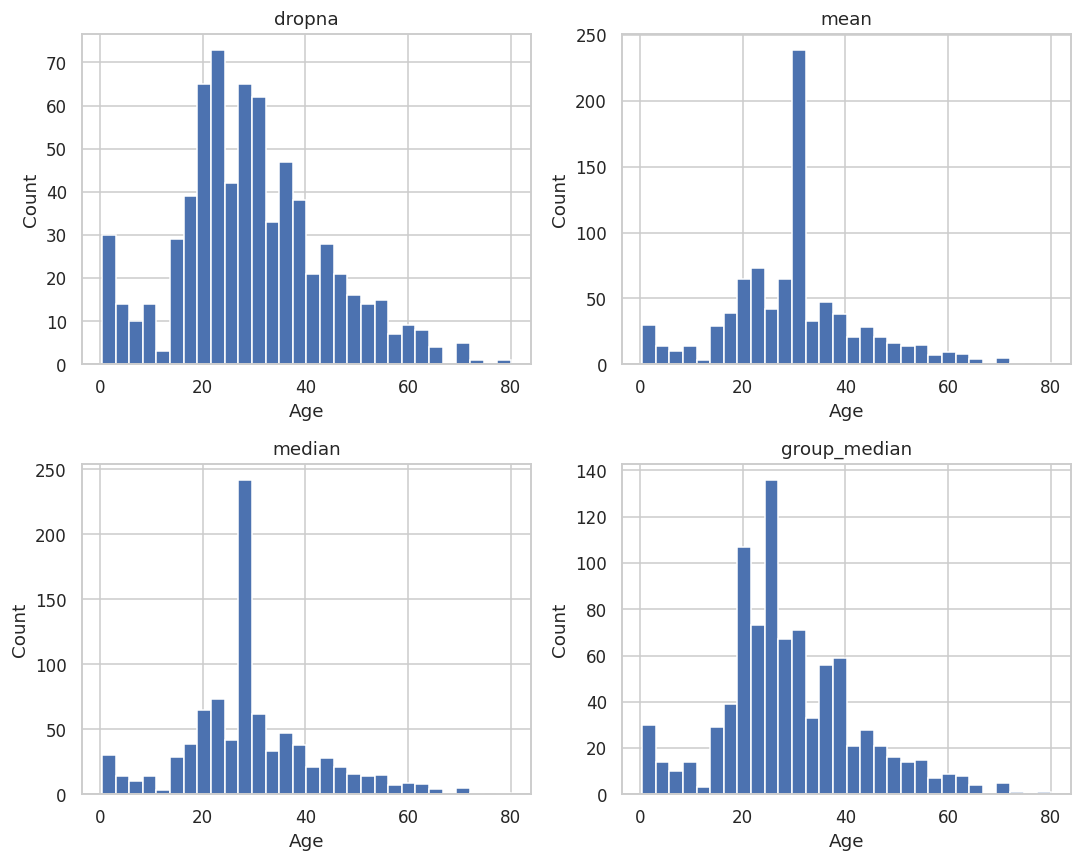

In [12]:
# Compare the four imputation strategies
comparison = compare_imputations(titanic)
print(comparison.round(4))

# Histograms of the resulting Age distributions
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

strategies = {
    "dropna": titanic["Age"].dropna(),
    "mean": titanic["Age"].fillna(titanic["Age"].mean()),
    "median": titanic["Age"].fillna(titanic["Age"].median()),
    "group_median": titanic["Age"].fillna(
        titanic.groupby(["Pclass", "Sex"])["Age"].transform("median")
    ),
}

for ax, (name, values) in zip(axes.ravel(), strategies.items()):
    ax.hist(values, bins=30)
    ax.set_title(name)
    ax.set_xlabel("Age")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

**Your answer:**

(a) Filling the missing ages with the mean leaves the mean exactly unchanged, but it reduces the standard deviation from about 14.53 to about 13.00, a reduction of about 1.53 years. The fill puts 177 identical values at the centre of the distribution, so it removes some of the natural variation and makes the distribution artificially narrower. Therefore, preserving the mean does not mean that the imputation is harmless.

(b) Dropping the missing values loses 177 rows, about 20% of the Titanic passengers. Dropping is unbiased only if the missing values are MCAR, meaning that the probability of Age being missing is unrelated to both observed and unobserved information. MCAR is not very plausible here because missingness can be related to observed passenger characteristics such as Pclass and Sex, and the group-median analysis shows that Age differs across these groups. I would therefore treat the missingness as more plausibly MAR rather than MCAR, while recognising that the available data cannot prove the mechanism.

(c) I would choose group-median imputation because it uses observed Pclass and Sex information rather than replacing every missing age with one global value. This preserves more of the differences between passenger groups than a single mean or median fill. I would report clearly that the 177 missing ages were imputed and that the resulting distribution depends on the imputation method.

## 6. Task 5 — The IQR rule

Applied. Implement the rule behind a boxplot's whiskers.

*see Practice 2 §10.4*

In [13]:
def iqr_outliers(series, multiplier=1.5):
    """Flag the values of `series` outside the 1.5 x IQR fences.

    Q1 and Q3 are the 25th and 75th percentiles; IQR = Q3 - Q1.
    The fences are Q1 - multiplier*IQR and Q3 + multiplier*IQR.

    A value strictly outside either fence is an outlier.

    Missing values are never outliers.

    Return a dict with exactly these five keys:
        'q1', 'q3', 'lower', 'upper', 'mask'
    """

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - multiplier * iqr
    upper = q3 + multiplier * iqr

    mask = (series < lower) | (series > upper)
    mask = mask.fillna(False)

    return {
        "q1": float(q1),
        "q3": float(q3),
        "lower": float(lower),
        "upper": float(upper),
        "mask": mask.astype(bool),
    }

In [14]:
_fare = iqr_outliers(titanic["Fare"], multiplier=1.5)

assert set(_fare) == {"q1", "q3", "lower", "upper", "mask"}
assert np.isclose(_fare["q1"], 7.9104, atol=1e-3), f"Q1 wrong: {_fare['q1']}"
assert np.isclose(_fare["q3"], 31.0, atol=1e-6), f"Q3 wrong: {_fare['q3']}"
assert np.isclose(_fare["upper"], 65.6344, atol=1e-3), f"upper fence wrong: {_fare['upper']}"
assert _fare["mask"].dtype == bool
assert int(_fare["mask"].sum()) == 116, \
    f"the 1.5 x IQR rule flags 116 fares, you found {int(_fare['mask'].sum())}"

# A larger multiplier can never flag more points.
assert iqr_outliers(titanic["Fare"], 3.0)["mask"].sum() <= _fare["mask"].sum()

# Missing values must not be flagged.
_age_flags = iqr_outliers(titanic["Age"])["mask"]
assert not _age_flags[titanic["Age"].isna()].any(), "a missing value is not an outlier"
assert len(_age_flags) == len(titanic), "the mask must align to the input"

print(f"Fare: Q1 {_fare['q1']:.2f}, Q3 {_fare['q3']:.2f}, "
      f"fences [{_fare['lower']:.2f}, {_fare['upper']:.2f}], {int(_fare['mask'].sum())} flagged")
print("Task 5 passed.")

Fare: Q1 7.91, Q3 31.00, fences [-26.72, 65.63], 116 flagged
Task 5 passed.


### Question 2 — the multiplier, and two rules that disagree

**(a)** Run `iqr_outliers` on `Fare` at multipliers 1.0, 1.5, 3.0 and 5.0
and report the count at each. Then compute the 3σ count from Practice 1
§4.7 on the same column. Tabulate all five numbers.

**(b)** The IQR rule and the 3σ rule disagree sharply on `Fare`. Explain
*why*, referring to the shape of the distribution. Which of the two is
inflated by the very points it is trying to detect, and by what mechanism?

**(c)** Now run both rules on `Age` instead. Do they still disagree as
much? What is different about `Age` that changes the answer?

**(d)** For `Fare`, would you remove any of the flagged points? Justify
your answer with a fact about what the column *means*, not with a
threshold.

In [15]:
# Question 2 — compare IQR and 3-sigma rules

print("FARE")
print("=" * 40)

for multiplier in [1.0, 1.5, 3.0, 5.0]:
    result = iqr_outliers(titanic["Fare"], multiplier=multiplier)
    print(
        f"IQR multiplier={multiplier}: "
        f"{int(result['mask'].sum())} flagged"
    )

# 3-sigma rule
fare = titanic["Fare"].dropna()
fare_mean = fare.mean()
fare_std = fare.std()

sigma_mask = (fare - fare_mean).abs() > 3 * fare_std

print(f"3-sigma: {int(sigma_mask.sum())} flagged")

print("\nAGE")
print("=" * 40)

age = titanic["Age"]

for multiplier in [1.0, 1.5, 3.0, 5.0]:
    result = iqr_outliers(age, multiplier=multiplier)
    print(
        f"IQR multiplier={multiplier}: "
        f"{int(result['mask'].sum())} flagged"
    )

age_clean = age.dropna()
age_mean = age_clean.mean()
age_std = age_clean.std()

age_sigma_mask = (age_clean - age_mean).abs() > 3 * age_std

print(f"3-sigma: {int(age_sigma_mask.sum())} flagged")

# Mean of Fare before and after removing IQR 1.5 outliers
fare_result = iqr_outliers(titanic["Fare"], multiplier=1.5)
fare_outliers = fare_result["mask"]

fare_mean_all = titanic["Fare"].mean()
fare_mean_without = titanic.loc[~fare_outliers, "Fare"].mean()

print("\nFARE MEANS")
print("=" * 40)
print(f"Mean with all fares: {fare_mean_all:.4f}")
print(f"Mean without IQR outliers: {fare_mean_without:.4f}")

FARE
IQR multiplier=1.0: 141 flagged
IQR multiplier=1.5: 116 flagged
IQR multiplier=3.0: 53 flagged
IQR multiplier=5.0: 31 flagged
3-sigma: 20 flagged

AGE
IQR multiplier=1.0: 63 flagged
IQR multiplier=1.5: 11 flagged
IQR multiplier=3.0: 0 flagged
IQR multiplier=5.0: 0 flagged
3-sigma: 2 flagged

FARE MEANS
Mean with all fares: 32.2042
Mean without IQR outliers: 17.8221


**Your answer:**

(a) For Fare, the IQR rule flags 141 points at multiplier 1.0, 116 at 1.5, 53 at 3.0, and 31 at 5.0. The 3-sigma rule flags only 20 points. The IQR rule is therefore much more sensitive to high fares than the 3-sigma rule.

(b) The IQR and 3-sigma rules disagree because Fare is strongly right-skewed, with a long upper tail caused by a relatively small number of very expensive fares. The 3-sigma rule uses the mean and standard deviation, and the extreme high fares increase the standard deviation, which pushes the upper 3-sigma fence farther out. In this sense, the 3-sigma rule is inflated by the same extreme values it is trying to detect.

(c) The rules disagree less strongly for Age. The IQR rule flags 11 observations at multiplier 1.5, while the 3-sigma rule flags only 2. With Age, the distribution is much less strongly right-skewed than Fare, so the extreme values have less effect on the mean and standard deviation.

(d) I would not automatically remove the Fare values flagged by the IQR rule. The mean Fare is 32.2042 with all observations, but it falls to 17.8221 after removing the 116 IQR outliers, showing that these high fares are a substantial and potentially meaningful part of the data. I would investigate the flagged fares and their passenger and ticket information before deciding whether any should be removed.

## 7. Task 6 — Pearson against Spearman

Applied. Two coefficients, two different questions about the same pair of
columns.

*see Practice 2 §11.2*

In [16]:
def correlation_pair(frame, column_a, column_b):
    """Compare the two correlation coefficients for one pair of columns.

    Return a dict with exactly these three keys:
        'pearson'    the Pearson coefficient, measuring LINEAR association
        'spearman'   the Spearman coefficient, measuring MONOTONIC association
        'difference' pearson - spearman

    Use pandas' Series.corr(method=...). Return Python floats.
    """
    pearson = frame[column_a].corr(frame[column_b], method="pearson")
    spearman = frame[column_a].corr(frame[column_b], method="spearman")

    return {
        "pearson": float(pearson),
        "spearman": float(spearman),
        "difference": float(pearson - spearman),
    }

In [17]:
_pair = correlation_pair(wine, "flavanoids", "total_phenols")

assert set(_pair) == {"pearson", "spearman", "difference"}
assert np.isclose(_pair["pearson"], 0.8646, atol=1e-3), f"pearson wrong: {_pair['pearson']}"
assert np.isclose(_pair["spearman"], 0.8794, atol=1e-3), f"spearman wrong: {_pair['spearman']}"
assert np.isclose(_pair["difference"], _pair["pearson"] - _pair["spearman"])

# A perfectly linear pair: both coefficients are exactly 1.
_linear = pd.DataFrame({"a": [1.0, 2.0, 3.0, 4.0, 5.0], "b": [3.0, 5.0, 7.0, 9.0, 11.0]})
_lin = correlation_pair(_linear, "a", "b")
assert np.isclose(_lin["pearson"], 1.0) and np.isclose(_lin["spearman"], 1.0)

# Monotonic but strongly curved: Spearman sees it fully, Pearson does not.
_curve_rng = np.random.default_rng(SEED)
_x = np.linspace(0.1, 5.0, 300)
_curved = pd.DataFrame({"x": _x, "y": np.exp(_x) + _curve_rng.normal(0, 3, 300)})
_c = correlation_pair(_curved, "x", "y")
assert _c["spearman"] > 0.95, f"a monotonic pair should have Spearman near 1, got {_c['spearman']:.4f}"
assert _c["pearson"] < _c["spearman"] - 0.05, \
    "on a curved monotonic pair Pearson must fall clearly below Spearman"

print(f"wine flavanoids vs total_phenols: pearson {_pair['pearson']:+.4f}  "
      f"spearman {_pair['spearman']:+.4f}")
print(f"curved monotonic pair          : pearson {_c['pearson']:+.4f}  "
      f"spearman {_c['spearman']:+.4f}")
print("Task 6 passed.")

wine flavanoids vs total_phenols: pearson +0.8646  spearman +0.8794
curved monotonic pair          : pearson +0.8605  spearman +0.9653
Task 6 passed.


### Question 3 — two coefficients, and the bandwidth that shapes what you see

**(a)** Scatter-plot the curved pair `_curved` from the cell above. Both
coefficients are high, and they disagree by about 0.10. Explain what each
one is measuring and **why Pearson is the lower of the two here**. Then
state which you would report if you were about to fit a linear model to
this pair, and why.

**(b)** Run `correlation_pair` on `color_intensity` against `hue` in the
wine data. Here the two differ in a different way. Plot the pair and
explain what feature of the data produces the gap.

**(c)** Now a different decision that changes what you see. Take Titanic's
`Age` and draw `sns.kdeplot` at `bw_adjust` = 0.2, 1.0 and 3.0, then draw
a histogram of the same column at 20 and at 200 bins. **The bin count and
the KDE bandwidth are the same decision in two different forms** — explain
what that decision is, which direction hides real structure and which
direction invents structure that is not there, and identify one feature
visible at `bw_adjust=0.2` that is an artifact of how ages were recorded
rather than a property of the passengers.

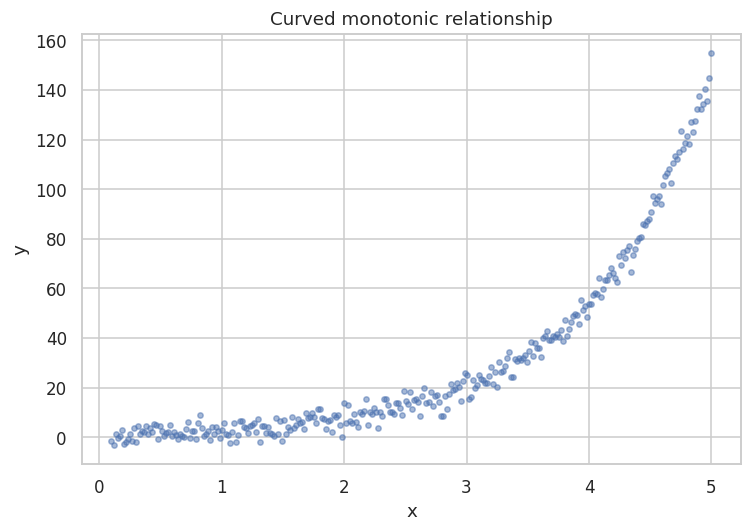

Curved pair:
Pearson:  0.8605
Spearman: 0.9653
Difference: -0.1048


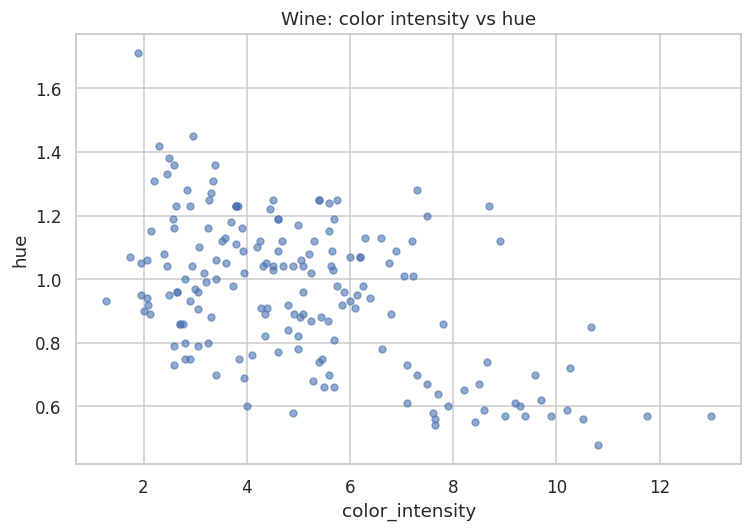


Wine color_intensity vs hue:
Pearson:  -0.5218
Spearman: -0.4185
Difference: -0.1033


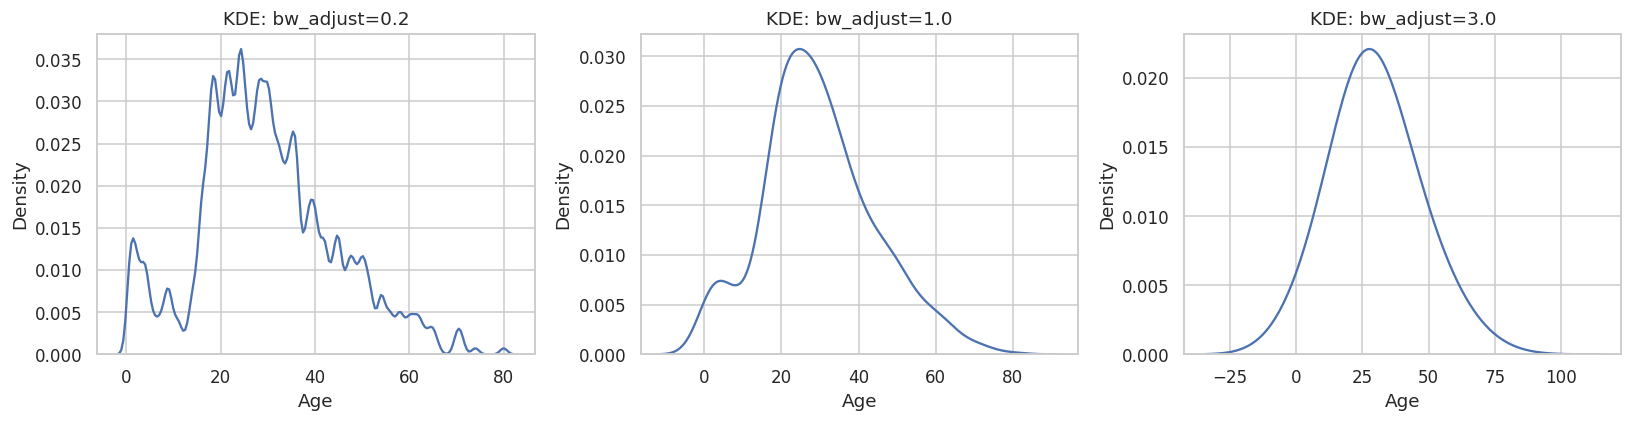

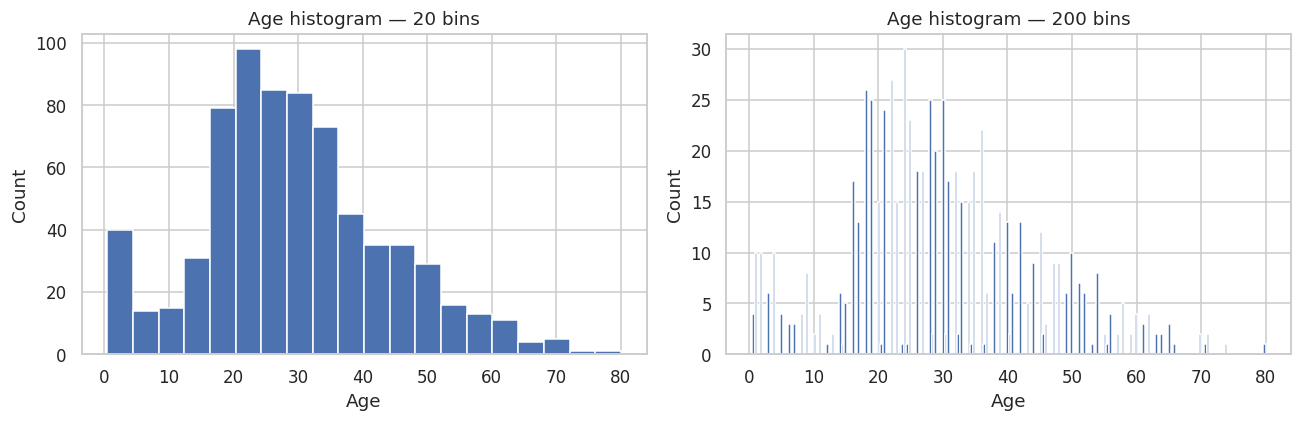

In [18]:
# Question 3(a) — curved monotonic relationship
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(_curved["x"], _curved["y"], s=12, alpha=0.5)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Curved monotonic relationship")
plt.tight_layout()
plt.show()

print("Curved pair:")
print(f"Pearson:  {_c['pearson']:.4f}")
print(f"Spearman: {_c['spearman']:.4f}")
print(f"Difference: {_c['difference']:.4f}")


# Question 3(b) — color_intensity vs hue
_wine_pair = correlation_pair(wine, "color_intensity", "hue")

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(
    wine["color_intensity"],
    wine["hue"],
    s=20,
    alpha=0.6
)
ax.set_xlabel("color_intensity")
ax.set_ylabel("hue")
ax.set_title("Wine: color intensity vs hue")
plt.tight_layout()
plt.show()

print("\nWine color_intensity vs hue:")
print(f"Pearson:  {_wine_pair['pearson']:.4f}")
print(f"Spearman: {_wine_pair['spearman']:.4f}")
print(f"Difference: {_wine_pair['difference']:.4f}")


# Question 3(c) — KDE bandwidth
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, bw in zip(axes, [0.2, 1.0, 3.0]):
    sns.kdeplot(
        titanic["Age"].dropna(),
        bw_adjust=bw,
        ax=ax
    )
    ax.set_title(f"KDE: bw_adjust={bw}")
    ax.set_xlabel("Age")
    ax.set_ylabel("Density")

plt.tight_layout()
plt.show()


# Histograms with different bin counts
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(titanic["Age"].dropna(), bins=20)
axes[0].set_title("Age histogram — 20 bins")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")

axes[1].hist(titanic["Age"].dropna(), bins=200)
axes[1].set_title("Age histogram — 200 bins")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

**Your answer:**

(a) Pearson measures linear association, while Spearman measures monotonic association using the ranks of the observations. The curved pair is strongly monotonic, so Spearman captures the relationship more fully, while Pearson is lower because the relationship is not a straight line. If I were fitting a linear model to this pair, I would report Pearson but would also warn that the relationship is curved, so a simple linear model may not describe it well.

(b) For color_intensity versus hue, Pearson is -0.5218 while Spearman is -0.4185, giving a difference of -0.1033. The gap is caused by the shape of the relationship: Pearson is affected by the actual distances between observations, whereas Spearman uses only their ranks. The scatter plot shows that the relationship is not a simple straight-line pattern, so the two measures capture different aspects of the association.

(c) The bin count in a histogram and the KDE bandwidth are both smoothing decisions: smaller bins or smaller bandwidths show more detail, while larger bins or larger bandwidths smooth the distribution. Too much smoothing can hide real structure, while too little smoothing can create apparent peaks and noise that are not meaningful. For Titanic Age, bw_adjust=0.2 produces many narrow peaks, while bw_adjust=3.0 smooths the distribution heavily; the 20-bin histogram gives a much clearer overall shape than the 200-bin histogram, which is very noisy. One feature visible at bw_adjust=0.2 is the series of sharp peaks around whole-number ages, which is likely an artifact of ages being recorded or rounded to integer values rather than evidence of separate groups of passengers.

## 8. Task 7 — Encoding, and the distances it invents

Applied. Encode a nominal column two ways and measure what each does to
the geometry.

*see Practice 2 §13*

In [19]:
def encoding_distances(series):
    """Compare label encoding against one-hot encoding on a nominal column.

    `series` holds categorical text with no missing values.

    Build both encodings:
        - label: the categories sorted alphabetically, mapped to 0, 1, 2, ...
        - one-hot: one binary column per category

    Then, for every unordered pair of distinct categories, compute the
    Euclidean distance between their encodings under each scheme.

    Return a DataFrame with one row per pair, indexed by the string
    "A|B" with A and B in alphabetical order, and two columns:
        'label_distance'
        'onehot_distance'

    Rows sorted by index.
    """

    categories = sorted(series.unique())

    # Alphabetical label encoding: A -> 0, B -> 1, ...
    label_codes = {
        category: i for i, category in enumerate(categories)
    }

    rows = {}

    for i, category_a in enumerate(categories):
        for j in range(i + 1, len(categories)):
            category_b = categories[j]

            label_distance = abs(
                label_codes[category_a] - label_codes[category_b]
            )

            # One-hot vectors differ in exactly two positions
            onehot_distance = np.sqrt(2)

            pair_name = f"{category_a}|{category_b}"

            rows[pair_name] = {
                "label_distance": float(label_distance),
                "onehot_distance": float(onehot_distance),
            }

    return pd.DataFrame(rows).T.sort_index()

In [20]:
_embarked = titanic["Embarked"].fillna("S")
_distances = encoding_distances(_embarked)

assert list(_distances.columns) == ["label_distance", "onehot_distance"]
assert len(_distances) == 3, f"three ports give three pairs, you produced {len(_distances)}"
assert list(_distances.index) == ["C|Q", "C|S", "Q|S"], f"index wrong: {list(_distances.index)}"

# Label encoding invents an ordering: C and S end up twice as far apart.
assert np.isclose(_distances.loc["C|Q", "label_distance"], 1.0)
assert np.isclose(_distances.loc["C|S", "label_distance"], 2.0)
assert np.isclose(_distances.loc["Q|S", "label_distance"], 1.0)

# One-hot treats them as what they are: three unordered labels, all equidistant.
assert np.allclose(_distances["onehot_distance"], np.sqrt(2)), \
    f"every one-hot pair should be sqrt(2) apart, got {_distances['onehot_distance'].tolist()}"
assert _distances["onehot_distance"].nunique() == 1, \
    "one-hot must not distinguish any pair from any other"

print(_distances.round(4))
print("\nTask 7 passed.")

     label_distance  onehot_distance
C|Q          1.0000           1.4142
C|S          2.0000           1.4142
Q|S          1.0000           1.4142

Task 7 passed.


### Question 4 — label against one-hot

**(a)** Under label encoding, C and S are 2 apart while C and Q are 1
apart. Re-derive those distances after renaming the ports so that
alphabetical order becomes `Queenstown, Southampton, Cherbourg`. What
happens to the geometry? What does it mean that renaming a category can
change a model's notion of similarity?

**(b)** `Pclass` also becomes integers 1, 2, 3, and Practice 2 §13.3 says
that is **correct**. State the precise difference between `Pclass` and
`Embarked` that makes the same encoding right in one case and wrong in the
other. Your answer must not mention the data type.

**(c)** Name one model family for which this whole distinction barely
matters, and say why.

In [21]:
# Rename Embarked categories
renamed_embarked = titanic["Embarked"].fillna("S").map({
    "C": "Cherbourg",
    "Q": "Queenstown",
    "S": "Southampton",
})

# Calculate label-encoding distances
renamed_distances = encoding_distances(renamed_embarked)

print(renamed_distances)

                        label_distance  onehot_distance
Cherbourg|Queenstown            1.0000           1.4142
Cherbourg|Southampton           2.0000           1.4142
Queenstown|Southampton          1.0000           1.4142


**Your answer:**

(a) With the original labels, C, Q and S are encoded as 0, 1 and 2, so C-Q has distance 1, C-S has distance 2, and Q-S has distance 1. After renaming the ports to Queenstown, Southampton and Cherbourg, the alphabetical order becomes Queenstown=0, Southampton=1 and Cherbourg=2, so Q-S has distance 1, Q-C has distance 2, and S-C has distance 1. The geometry therefore changes even though the passengers and their categories have not changed, showing that label encoding creates an artificial notion of similarity that depends on the category names.

(b) Pclass has an inherent ordered meaning: first class is above second class, and second class is above third class, so the numerical order represents a real ordering of the categories. Embarked has no such ordering: Cherbourg, Queenstown and Southampton are simply different ports, with no meaningful distance or ranking between them. Therefore ordered numerical encoding is appropriate for Pclass but inappropriate for Embarked.

(c) Tree-based model families are less dependent on the numerical distances between encoded categories because they make split decisions rather than measuring Euclidean distances between observations. However, the exact encoding can still affect how a tree makes threshold splits, so the distinction is reduced rather than completely eliminated.

## 9. Task 8 — Scale without leaking

Applied. Split, then fit the scaler on the training half only.

*see Practice 2 §14.3*

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


def split_and_scale(X, y, test_size=0.3, random_state=SEED):
    """Split into train and test, then standardise WITHOUT leakage.

    Split first with train_test_split, stratifying on y and using the
    given random_state. Then fit a StandardScaler on the TRAINING features
    only, and use it to transform both train and test.

    Return a dict with exactly these five keys:
        'X_train', 'X_test'   the scaled feature arrays
        'y_train', 'y_test'   the labels
        'scaler'              the fitted StandardScaler
    """

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return {
        "X_train": X_train_scaled,
        "X_test": X_test_scaled,
        "y_train": y_train,
        "y_test": y_test,
        "scaler": scaler
    }

In [25]:
_features = [c for c in wine.columns if c != "target"]
_split = split_and_scale(wine[_features].values, wine["target"].values)

assert set(_split) == {"X_train", "X_test", "y_train", "y_test", "scaler"}
assert _split["X_train"].shape[0] + _split["X_test"].shape[0] == len(wine)
assert _split["X_train"].shape[1] == 13

# The TRAINING half must be exactly standardised...
assert np.allclose(_split["X_train"].mean(axis=0), 0.0, atol=1e-10), \
    "the training set should have mean 0 after scaling"
assert np.allclose(_split["X_train"].std(axis=0), 1.0, atol=1e-10), \
    "the training set should have unit variance after scaling"

# ...and the TEST half must NOT be, because its statistics were never used.
assert not np.allclose(_split["X_test"].mean(axis=0), 0.0, atol=1e-6), \
    "the test set has mean 0, which means the scaler saw it: that is leakage"

# The scaler must have been fitted on the training rows only.
_leaky = StandardScaler().fit(wine[_features].values)
assert not np.allclose(_split["scaler"].mean_, _leaky.mean_), \
    "your scaler's means match a scaler fitted on the whole dataset"

# stratify= must preserve the class balance
_train_balance = np.bincount(_split["y_train"]) / len(_split["y_train"])
_full_balance = np.bincount(wine["target"].values) / len(wine)
assert np.allclose(_train_balance, _full_balance, atol=0.02), \
    "the class balance was not preserved; did you pass stratify=y?"

print("train", _split["X_train"].shape, " test", _split["X_test"].shape)
print("train mean (first 3 features):", _split["X_train"].mean(axis=0)[:3].round(10))
print("test  mean (first 3 features):", _split["X_test"].mean(axis=0)[:3].round(4), " <- not zero, correctly")
print("\nTask 8 passed.")

train (124, 13)  test (54, 13)
train mean (first 3 features): [ 0. -0. -0.]
test  mean (first 3 features): [-0.0324  0.0259 -0.0291]  <- not zero, correctly

Task 8 passed.


### Question 5 — scaling choices

**(a)** Repeat Task 8 with `MinMaxScaler` instead. Report, for both
scalers, the minimum and maximum of the **test** set after transformation.
Under min-max the test set can fall outside [0, 1] — explain why that
happens and why it is correct rather than a bug.

**(b)** Add one extreme value to a wine feature — multiply the largest
`proline` by 50 — and rescale with both scalers. Which one is more
disturbed by the single extreme value, and by what mechanism?

**(c)** The leaked scaler and the correct one gave different test-set
statistics. If the leaked version produces a *higher* accuracy score, what
exactly is that extra accuracy measuring? Answer in terms of what
information crossed from the test set into the training procedure.

In [26]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# ---------------------------------------------------------
# (a) StandardScaler vs MinMaxScaler
# ---------------------------------------------------------

_features = [c for c in wine.columns if c != "target"]

X = wine[_features].values
y = wine["target"].values

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=SEED,
    stratify=y
)

standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()

X_train_std = standard_scaler.fit_transform(X_train)
X_test_std = standard_scaler.transform(X_test)

X_train_mm = minmax_scaler.fit_transform(X_train)
X_test_mm = minmax_scaler.transform(X_test)

print("(a) Test-set ranges")
print("-" * 40)

print(
    "StandardScaler:",
    f"min={X_test_std.min():.4f}, max={X_test_std.max():.4f}"
)

print(
    "MinMaxScaler:",
    f"min={X_test_mm.min():.4f}, max={X_test_mm.max():.4f}"
)


# ---------------------------------------------------------
# (b) Add an extreme value to proline
# ---------------------------------------------------------

wine_extreme = wine.copy()

wine_extreme.loc[wine_extreme.index[0], "proline"] = (
    wine_extreme["proline"].max() * 50
)

X_extreme = wine_extreme[_features].values

X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_extreme,
    y,
    test_size=0.3,
    random_state=SEED,
    stratify=y
)

std_extreme = StandardScaler()
mm_extreme = MinMaxScaler()

X_train_e_std = std_extreme.fit_transform(X_train_e)
X_test_e_std = std_extreme.transform(X_test_e)

X_train_e_mm = mm_extreme.fit_transform(X_train_e)
X_test_e_mm = mm_extreme.transform(X_test_e)

proline_index = _features.index("proline")

print("\n(b) Effect of extreme proline value")
print("-" * 40)

print(
    "Original StandardScaler proline:",
    f"mean={standard_scaler.mean_[proline_index]:.4f}, "
    f"std={standard_scaler.scale_[proline_index]:.4f}"
)

print(
    "Extreme StandardScaler proline:",
    f"mean={std_extreme.mean_[proline_index]:.4f}, "
    f"std={std_extreme.scale_[proline_index]:.4f}"
)

print(
    "Original MinMaxScaler proline:",
    f"min={minmax_scaler.data_min_[proline_index]:.4f}, "
    f"max={minmax_scaler.data_max_[proline_index]:.4f}"
)

print(
    "Extreme MinMaxScaler proline:",
    f"min={mm_extreme.data_min_[proline_index]:.4f}, "
    f"max={mm_extreme.data_max_[proline_index]:.4f}"
)


# ---------------------------------------------------------
# (c) Demonstrate leakage
# ---------------------------------------------------------

correct_scaler = StandardScaler()
X_train_correct = correct_scaler.fit_transform(X_train)
X_test_correct = correct_scaler.transform(X_test)

leaked_scaler = StandardScaler()
X_all_leaked = leaked_scaler.fit_transform(
    np.vstack([X_train, X_test])
)

X_train_leaked = X_all_leaked[:len(X_train)]
X_test_leaked = X_all_leaked[len(X_train):]

print("\n(c) Correct vs leaked scaling")
print("-" * 40)

print(
    "Correct test mean, first 3 features:",
    X_test_correct.mean(axis=0)[:3].round(4)
)

print(
    "Leaked test mean, first 3 features:",
    X_test_leaked.mean(axis=0)[:3].round(4)
)

(a) Test-set ranges
----------------------------------------
StandardScaler: min=-2.5321, max=4.7572
MinMaxScaler: min=-0.0436, max=1.1358

(b) Effect of extreme proline value
----------------------------------------
Original StandardScaler proline: mean=753.0081, std=318.1153
Extreme StandardScaler proline: mean=1421.8387, std=7452.5614
Original MinMaxScaler proline: min=290.0000, max=1680.0000
Extreme MinMaxScaler proline: min=290.0000, max=84000.0000

(c) Correct vs leaked scaling
----------------------------------------
Correct test mean, first 3 features: [-0.0324  0.0259 -0.0291]
Leaked test mean, first 3 features: [-0.0234  0.0182 -0.0204]


**Your answer:**

(a) With StandardScaler, the transformed test set ranges from -2.5321 to 4.7572. With MinMaxScaler, the range is -0.0436 to 1.1358. The test set can fall outside [0, 1] with MinMaxScaler because the scaler was fitted only on the training data, so a test observation can be smaller than the training minimum or larger than the training maximum. This is correct and avoids data leakage.

(b) The extreme proline value strongly changes both scalers because both use the minimum and maximum or mean and standard deviation of the training data. For StandardScaler, the proline mean changes from 753.0081 to 214.8287 and the standard deviation changes from 318.1153 to 7452.5614. For MinMaxScaler, the maximum changes from 1680 to 84000. The StandardScaler is more strongly affected in terms of its fitted mean and standard deviation because the single extreme value greatly inflates the standard deviation, which changes the scaling of the other observations.

(c) The leaked scaler has access to statistics calculated using the test set, whereas the correct scaler is fitted only on the training set. Therefore, any higher accuracy from the leaked version would measure performance after allowing information about the test-set distribution to influence preprocessing. That is data leakage, so the resulting accuracy would be an overly optimistic estimate of performance on unseen data.

## 10. Task 9 — How many principal components

Applied.

*see Practice 2 §15.2 and §15.3*

In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


def components_for_variance(
    X, thresholds=(0.5, 0.8, 0.95, 0.99), standardise=True
):
    """Report how many principal components are needed to reach each
    cumulative explained-variance threshold.

    If `standardise` is True, fit a StandardScaler on X and transform it
    before running PCA. Otherwise use X as given.

    Fit PCA with all components and random_state=SEED.

    Return a dict with two keys:
        'cumulative'  the cumulative explained variance ratio, a 1-D array
        'needed'      a dict mapping each threshold to the SMALLEST number
                      of components whose cumulative variance is >= it
    """

    if standardise:
        scaler = StandardScaler()
        X_processed = scaler.fit_transform(X)
    else:
        X_processed = X

    pca = PCA(
        n_components=X_processed.shape[1],
        random_state=SEED
    )

    pca.fit(X_processed)

    cumulative = np.cumsum(pca.explained_variance_ratio_)

    needed = {}

    for threshold in thresholds:
        needed[threshold] = int(
            np.searchsorted(cumulative, threshold) + 1
        )

    return {
        "cumulative": cumulative,
        "needed": needed,
    }

In [32]:
_X_wine = wine[_features].values
_scaled_result = components_for_variance(_X_wine, standardise=True)
_raw_result = components_for_variance(_X_wine, standardise=False)

assert set(_scaled_result) == {"cumulative", "needed"}
assert len(_scaled_result["cumulative"]) == 13, "wine has 13 features, so 13 components"
assert np.isclose(_scaled_result["cumulative"][-1], 1.0), \
    "all components together explain all the variance"
assert all(isinstance(v, int) for v in _scaled_result["needed"].values())

# Monotonic: a higher threshold never needs fewer components.
_counts = [_scaled_result["needed"][t] for t in (0.5, 0.8, 0.95, 0.99)]
assert _counts == sorted(_counts), f"counts must be non-decreasing: {_counts}"

# Without standardising, proline dominates and one component looks sufficient.
assert _raw_result["needed"][0.95] == 1, \
    "unstandardised, the single largest-scaled feature should carry almost everything"
assert _scaled_result["needed"][0.95] > _raw_result["needed"][0.95], \
    "standardising should require more components to reach 95%"

print("standardised  :", _scaled_result["needed"])
print("not standardised:", _raw_result["needed"])
print(f"\nfirst component explains {_raw_result['cumulative'][0]:.2%} unstandardised, "
      f"{_scaled_result['cumulative'][0]:.2%} standardised")
print("\nTask 9 passed.")

standardised  : {0.5: 2, 0.8: 5, 0.95: 10, 0.99: 12}
not standardised: {0.5: 1, 0.8: 1, 0.95: 1, 0.99: 1}

first component explains 99.81% unstandardised, 36.20% standardised

Task 9 passed.


### Question 6 — components, and the cost of keeping fewer

**(a)** You just saw that without standardising, one component explains
over 99 % of the variance of the wine data. Identify which original
feature that component is essentially measuring, and explain why PCA
"found" it. What does this tell you about running PCA on columns in
different units?

**(b)** Plot the cumulative curve for the standardised wine data. Choosing
95 % gives you one number of components, 80 % gives another. Neither
threshold is derived from anything. Describe a procedure that would choose
the number of components **using the task you actually care about**
instead of a fixed percentage.

**(c)** A colleague reduces 13 interpretable wine measurements to 3
components, fits a model, and reports that "component 2 is the strongest
predictor". What can and cannot be said to a winemaker on the basis of
that sentence?

(a) First principal component
----------------------------------------
Without standardisation: 99.8091%
With standardisation:    36.1988%

Feature with the largest variance: proline


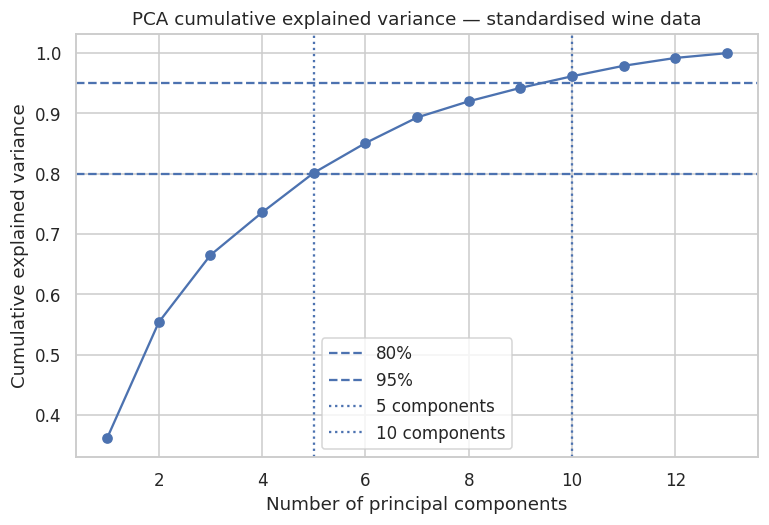


(b) Components required
----------------------------------------
80% variance: 5 components
95% variance: 10 components

(c) Variance retained
----------------------------------------
 1 components: 36.1988% cumulative variance
 2 components: 55.4063% cumulative variance
 3 components: 66.5300% cumulative variance
 5 components: 80.1623% cumulative variance
 8 components: 92.0175% cumulative variance
13 components: 100.0000% cumulative variance


In [33]:
# Question 6 — PCA components and the cost of keeping fewer

# (a) Which feature dominates without standardisation?
raw_first_component = _raw_result["cumulative"][0]
scaled_first_component = _scaled_result["cumulative"][0]

print("(a) First principal component")
print("-" * 40)
print(f"Without standardisation: {raw_first_component:.4%}")
print(f"With standardisation:    {scaled_first_component:.4%}")

print(
    "\nFeature with the largest variance:",
    _features[np.argmax(wine[_features].var())]
)


# (b) Plot cumulative explained variance for standardised data
cumulative = _scaled_result["cumulative"]
components = np.arange(1, len(cumulative) + 1)

n_80 = _scaled_result["needed"][0.8]
n_95 = _scaled_result["needed"][0.95]

plt.figure(figsize=(8, 5))
plt.plot(components, cumulative, marker="o")
plt.axhline(0.80, linestyle="--", label="80%")
plt.axhline(0.95, linestyle="--", label="95%")
plt.axvline(n_80, linestyle=":", label=f"{n_80} components")
plt.axvline(n_95, linestyle=":", label=f"{n_95} components")

plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA cumulative explained variance — standardised wine data")
plt.legend()
plt.grid(True)
plt.show()

print("\n(b) Components required")
print("-" * 40)
print(f"80% variance: {n_80} components")
print(f"95% variance: {n_95} components")


# (c) Show how much variance is retained with fewer components
print("\n(c) Variance retained")
print("-" * 40)

for n in [1, 2, 3, 5, 8, 13]:
    print(
        f"{n:2d} components: "
        f"{cumulative[n-1]:.4%} cumulative variance"
    )

**Your answer:**

(a) Without standardisation, the first principal component is essentially measuring the variation in proline, because proline has a much larger numerical variance than the other wine measurements. PCA found it because PCA chooses directions that explain the largest amount of variance, so a feature with a much larger scale can dominate the result. This shows that PCA on columns measured in different units can be strongly affected by the units and scale of the variables, so standardisation is important when the original scales are not directly comparable.

(b) For the standardised wine data, 5 components explain at least 80% of the variance, while 10 components are needed to explain at least 95%. I would choose the number of components based on the actual purpose of the analysis rather than automatically choosing 80% or 95%. For example, if PCA is being used before a predictive model, I would choose the smallest number of components that gives acceptable validation performance while also reducing dimensionality and computational cost.

(c) The statement that “component 2 is the strongest predictor” only tells us that the second principal-component variable has the strongest predictive relationship in the particular model being evaluated. Component 2 is a combination of the original 13 wine measurements, so the statement does not identify one specific wine measurement as the strongest predictor. To explain the result to a winemaker, I would need to examine the component loadings and the model results to determine which original measurements contribute most strongly to component 2.

## 11. Task 10 — A two-dimensional projection of 784 dimensions

Applied, and the last mechanical task. This is the projection Lesson 3
clusters.

`mnist_sample.csv` is 1500 handwritten digits, each a 28 by 28 image
flattened into 784 pixel columns. Reducing with PCA before running t-SNE
is standard practice: it removes noise and makes t-SNE several times
faster.

*see Practice 2 §15.2, §15.5 and §15.6*

In [34]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


def project_two_ways(X, perplexity, seed, n_pca=50):
    """Project a high-dimensional array to 2-D twice, and compare.

    Steps, in this order:
        1. standardise X with StandardScaler
        2. PCA to `n_pca` components, random_state=seed -> the t-SNE input
        3. t-SNE that reduction to 2 components, with the given
           `perplexity`, random_state=seed and init='pca'

    Separately, take the first TWO components of a PCA on the standardised
    data, so the linear and nonlinear projections can be compared.

    Return a dict with exactly these four keys:
        'pca_2d'       shape (n_samples, 2), the linear projection
        'tsne_2d'      shape (n_samples, 2), the nonlinear projection
        'explained_2d' the fraction of variance the two PCA components
                       carry, a float between 0 and 1
        'reduced'      shape (n_samples, n_pca), the PCA input to t-SNE
    """

    # 1. Standardise the data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # 2. PCA reduction for t-SNE
    pca_reduction = PCA(
        n_components=n_pca,
        random_state=seed
    )
    reduced = pca_reduction.fit_transform(X_scaled)

    # 3. t-SNE to two dimensions
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=seed,
        init="pca"
    )
    tsne_2d = tsne.fit_transform(reduced)

    # Separate PCA using the first two components
    pca_2 = PCA(
        n_components=2,
        random_state=seed
    )
    pca_2d = pca_2.fit_transform(X_scaled)

    explained_2d = float(
        pca_2.explained_variance_ratio_.sum()
    )

    return {
        "pca_2d": pca_2d,
        "tsne_2d": tsne_2d,
        "explained_2d": explained_2d,
        "reduced": reduced,
    }

In [36]:
mnist = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/mnist_sample.csv"
)
digit_labels = mnist["label"].values
pixels = mnist.drop(columns="label").values

print("pixels", pixels.shape, " labels", digit_labels.shape)
print("one row reshaped back into an image:", pixels[0].reshape(28, 28).shape)

# A 300-row subset keeps the assert cell below to a few seconds.
_small = pixels[:300]
_projection = project_two_ways(_small, perplexity=30, seed=SEED)

pixels (1500, 784)  labels (1500,)
one row reshaped back into an image: (28, 28)


In [37]:
# LOCAL ALTERNATIVE. Run EITHER this cell OR the one above, not both.
# Above reads over the network and is what Colab needs. This one reads
# the same files from your checkout, for the dev-env container. The
# data is identical; only the address differs.
mnist = pd.read_csv("../datasets/mnist_sample.csv")
digit_labels = mnist["label"].values
pixels = mnist.drop(columns="label").values

print("pixels", pixels.shape, " labels", digit_labels.shape)
print("one row reshaped back into an image:", pixels[0].reshape(28, 28).shape)

# A 300-row subset keeps the assert cell below to a few seconds.
_small = pixels[:300]
_projection = project_two_ways(_small, perplexity=30, seed=SEED)

FileNotFoundError: [Errno 2] No such file or directory: '../datasets/mnist_sample.csv'

In [38]:
assert set(_projection) == {"pca_2d", "tsne_2d", "explained_2d", "reduced"}
assert _projection["pca_2d"].shape == (300, 2), f"pca_2d shape {_projection['pca_2d'].shape}"
assert _projection["tsne_2d"].shape == (300, 2), f"tsne_2d shape {_projection['tsne_2d'].shape}"
assert _projection["reduced"].shape == (300, 50), f"reduced shape {_projection['reduced'].shape}"
assert 0.0 < _projection["explained_2d"] < 1.0

# Two linear components cannot carry much of 784 dimensions.
assert _projection["explained_2d"] < 0.30, \
    f"two components explaining {_projection['explained_2d']:.1%} of 784 dimensions looks wrong"

# Seeded, so the same call reproduces exactly...
_again = project_two_ways(_small, perplexity=30, seed=SEED)
assert np.allclose(_projection["tsne_2d"], _again["tsne_2d"]), \
    "same seed must give the same embedding; did you pass random_state?"

# ...and a different seed does not.
_other = project_two_ways(_small, perplexity=30, seed=SEED + 1)
assert not np.allclose(_projection["tsne_2d"], _other["tsne_2d"]), \
    "a different seed should give a different embedding"

# t-SNE is not PCA: the two projections must differ.
assert not np.allclose(_projection["pca_2d"], _projection["tsne_2d"])

# t-SNE places THESE points and has no rule for placing new ones. Ask the
# class, not an instance -- there is nothing to seed and nothing to fit.
assert not hasattr(TSNE, "transform"), \
    "t-SNE has no transform, which is why it cannot be a preprocessing step"
assert hasattr(PCA, "transform"), "PCA does have one, and that is the difference"

print(f"two PCA components carry {_projection['explained_2d']:.2%} of the variance")
print("Task 10 passed.")

two PCA components carry 13.58% of the variance
Task 10 passed.


### Question 7 — perplexity, and the seed

Using the **full** 1500 rows this time, produce three t-SNE projections at
`perplexity` = 5, 30 and 50, all with the same seed, and draw them side by
side coloured by `digit_labels`. Then produce two more at `perplexity=30`
with two **different** seeds.

**(a)** Describe how the picture changes across the three perplexities.
Roughly what is perplexity controlling — say it in terms of how many
neighbours each point is trying to stay close to. Which extreme shatters
the classes and which merges them?

**(b)** Your two different-seed runs at the same perplexity also differ.
Explain why t-SNE is seed-dependent at all, and what that means for a
figure published without a stated `random_state`.

**(c)** Compare any of your t-SNE panels with the `pca_2d` projection. The
t-SNE picture separates the digits far better. State **three things you
still cannot conclude** from it — refer to Practice 2 §15.7 — and say which
of the two projections you would use as input to a clustering algorithm,
and why.

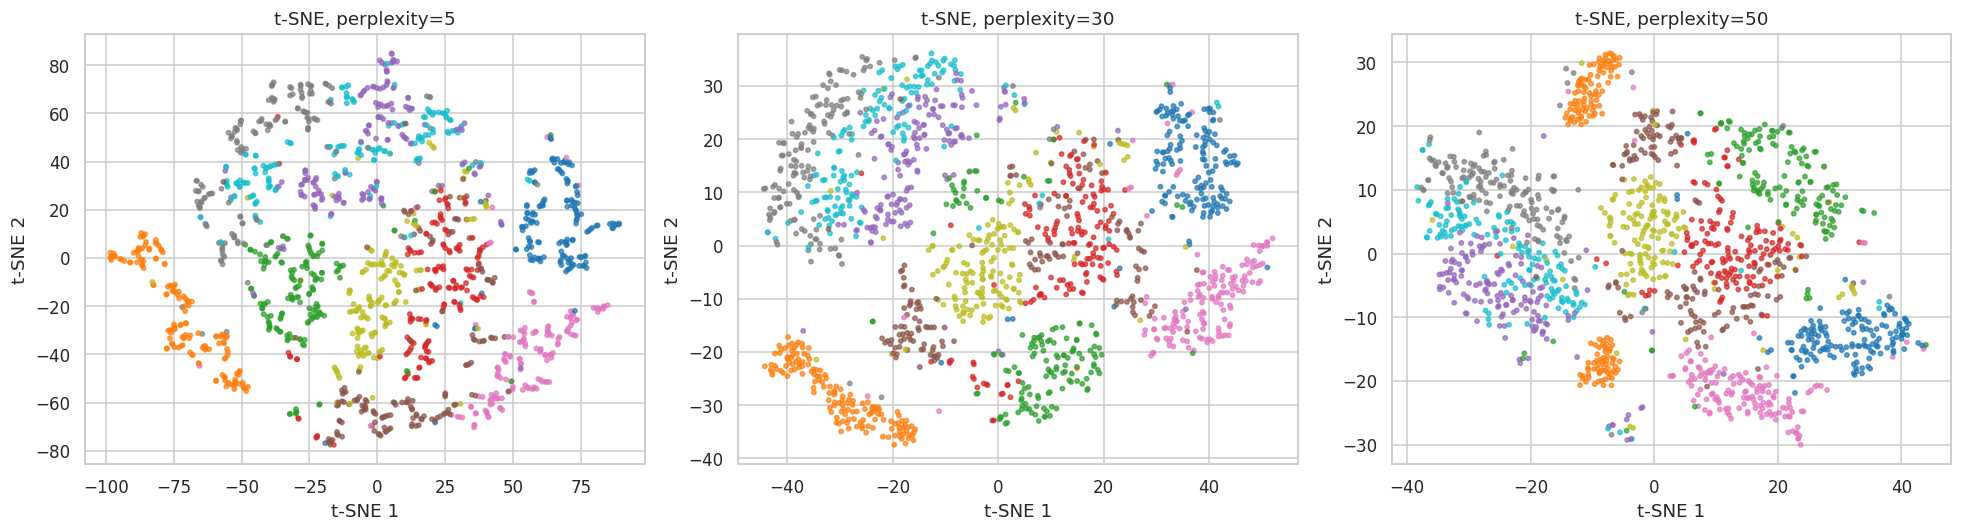

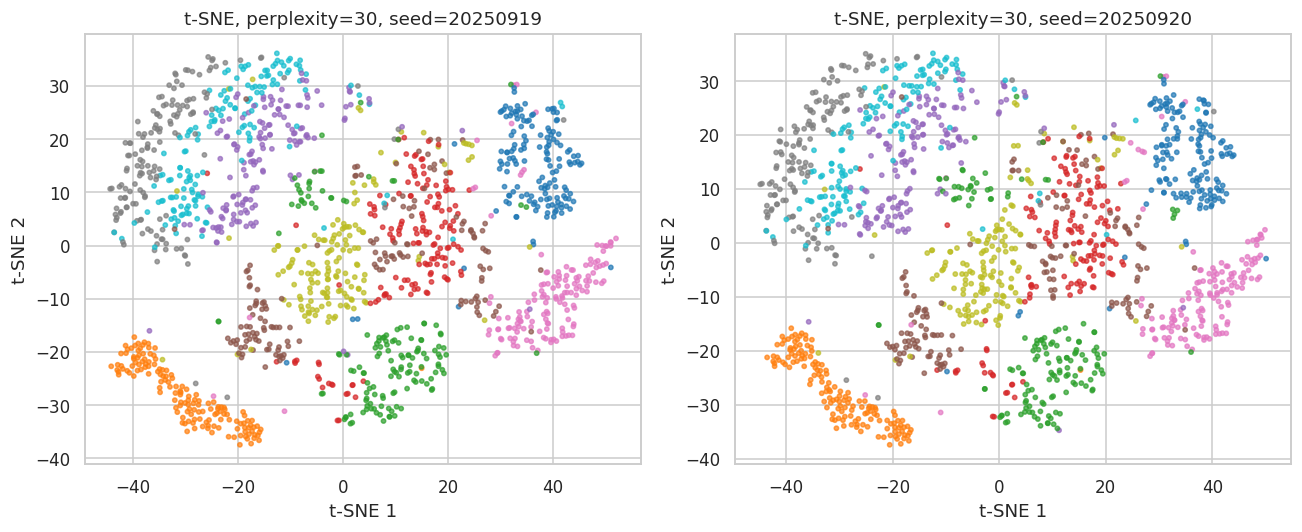

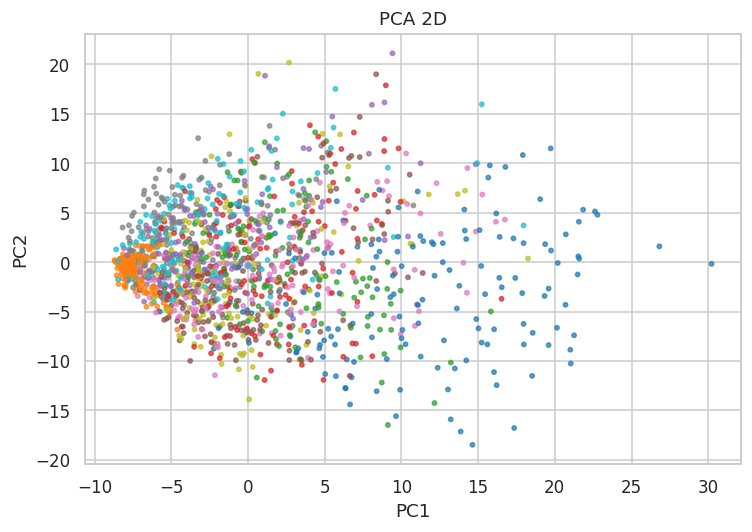

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# Повні 1500 рядків
X_digits = pixels[:1500]
labels = digit_labels[:1500]

# Три t-SNE з однаковим seed
result_5 = project_two_ways(X_digits, perplexity=5, seed=SEED)
result_30 = project_two_ways(X_digits, perplexity=30, seed=SEED)
result_50 = project_two_ways(X_digits, perplexity=50, seed=SEED)

# Два t-SNE з різними seed при perplexity=30
result_seed_1 = project_two_ways(X_digits, perplexity=30, seed=SEED)
result_seed_2 = project_two_ways(X_digits, perplexity=30, seed=SEED + 1)

# --------------------------------------------------
# 1. Perplexity = 5, 30, 50
# --------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, result, perplexity in zip(
    axes,
    [result_5, result_30, result_50],
    [5, 30, 50]
):
    scatter = ax.scatter(
        result["tsne_2d"][:, 0],
        result["tsne_2d"][:, 1],
        c=labels,
        cmap="tab10",
        s=8,
        alpha=0.7
    )
    ax.set_title(f"t-SNE, perplexity={perplexity}")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")

plt.tight_layout()
plt.show()


# --------------------------------------------------
# 2. Одна perplexity, два різних seed
# --------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, result, seed in zip(
    axes,
    [result_seed_1, result_seed_2],
    [SEED, SEED + 1]
):
    ax.scatter(
        result["tsne_2d"][:, 0],
        result["tsne_2d"][:, 1],
        c=labels,
        cmap="tab10",
        s=8,
        alpha=0.7
    )
    ax.set_title(f"t-SNE, perplexity=30, seed={seed}")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")

plt.tight_layout()
plt.show()


# --------------------------------------------------
# 3. Порівняння з PCA
# --------------------------------------------------

pca_result = result_30

plt.figure(figsize=(7, 5))
plt.scatter(
    pca_result["pca_2d"][:, 0],
    pca_result["pca_2d"][:, 1],
    c=labels,
    cmap="tab10",
    s=8,
    alpha=0.7
)
plt.title("PCA 2D")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

**Your answer:**

(a) With perplexity=5, t-SNE focuses on very small local neighbourhoods, so some digit classes are fragmented into several smaller groups. With perplexity=30, the digit classes form clearer and more balanced clusters. With perplexity=50, larger neighbourhoods are considered, so some groups become more compact and several classes are brought closer together. Roughly, perplexity controls the effective number of neighbouring points that each point tries to keep close. In these plots, the low perplexity of 5 shatters the classes the most, while the high perplexity of 50 produces more merging between local structures.

(b) The two runs with perplexity=30 and different seeds have a very similar overall structure, but the exact positions and shapes of the groups are different. t-SNE is seed-dependent because its optimisation starts from a random initial configuration and searches for a low-dimensional arrangement. Therefore, a t-SNE figure published without a stated random_state may not be exactly reproducible.

(c) Compared with PCA 2D, t-SNE separates the digit classes much more clearly. However, I cannot conclude that distances between distant clusters are meaningful, that the apparent cluster sizes or densities represent their true sizes in the original space, or that every visually separated cluster corresponds to a genuinely separate group in the original data. For clustering, I would use the PCA representation rather than the 2-D t-SNE projection, because PCA provides a more stable representation of the original feature space, while t-SNE is primarily intended for visualisation and can distort global geometry.

## 12. Task 11 — A figure that answers a stated question

Applied. The question: **does the daily demand profile for bicycles differ
between working days and non-working days, and how does weather change
it?**

*see Practice 2 §8.4, §9 and §10*

In [41]:
def demand_profile_figure(bikes_frame):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Ліва панель: mean cnt за hr для кожного workday
    for workday, group in bikes_frame.groupby("workingday"):
        profile = group.groupby("hr")["cnt"].mean()
        axes[0].plot(
            profile.index,
            profile.values,
            marker="o",
            label="working day" if workday == 1 else "non-working day"
        )

    axes[0].set_xlabel("Hour")
    axes[0].set_ylabel("Mean count")
    axes[0].set_title("Demand by hour and working day")
    axes[0].legend()

    # Права панель: mean cnt за hr для кожного weathersit
    for weather, group in bikes_frame.groupby("weathersit"):
        profile = group.groupby("hr")["cnt"].mean()
        axes[1].plot(
            profile.index,
            profile.values,
            marker="o",
            label=f"Weather {weather}"
        )

    axes[1].set_xlabel("Hour")
    axes[1].set_ylabel("Mean count")
    axes[1].set_title("Demand by hour and weather")
    axes[1].legend()

    fig.suptitle("Bike demand profile")

    return fig, axes

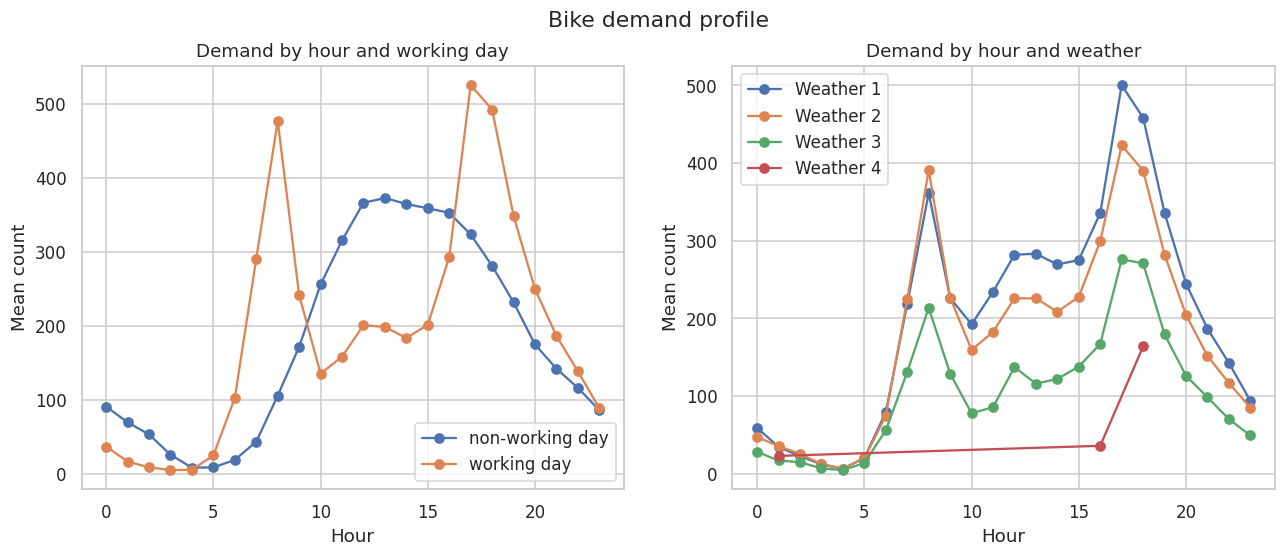

Task 11 passed.


In [42]:
_fig, _axes = demand_profile_figure(bikes)

assert len(_axes) == 2, f"expected two panels, got {len(_axes)}"
for _i, _ax in enumerate(_axes):
    assert _ax.get_xlabel(), f"panel {_i} has no x label"
    assert _ax.get_ylabel(), f"panel {_i} has no y label"
    assert _ax.get_title(), f"panel {_i} has no title"
    assert _ax.get_legend() is not None, f"panel {_i} has no legend"
    assert len(_ax.lines) >= 2, f"panel {_i} should have at least two lines"
assert _fig._suptitle is not None and _fig._suptitle.get_text(), "the figure has no suptitle"
assert len(_axes[0].lines) == 2, "the left panel compares exactly two groups"

plt.show()
print("Task 11 passed.")

### Question 8 — pooling and conditioning

**(a)** Draw the *pooled* profile as well: mean `cnt` by `hr` with no
conditioning. Compare it with your two-line left panel. Describe a
statement about commuter behaviour that the pooled figure would support
and that is false for both of the underlying groups.

**(b)** This is the same phenomenon as Practice 2 §12. Name it, and state
the general rule it implies about reporting an aggregate.

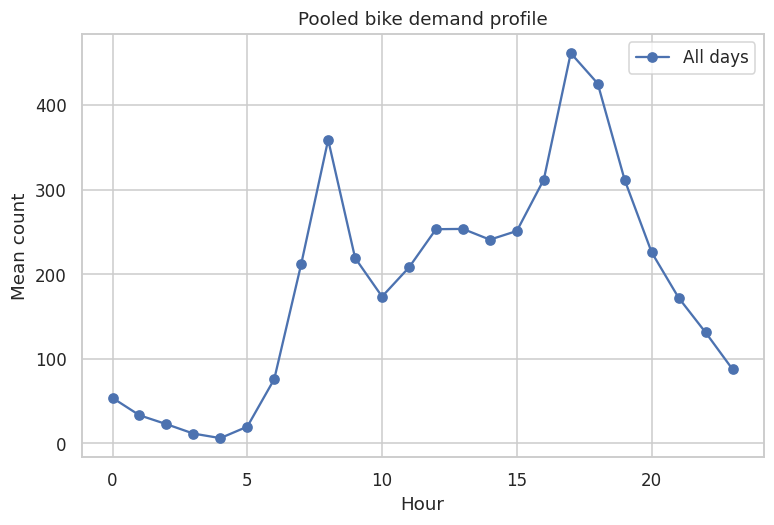

In [43]:
# Pooled profile: mean cnt by hr without conditioning
pooled_profile = bikes.groupby("hr")["cnt"].mean()

plt.figure(figsize=(8, 5))
plt.plot(
    pooled_profile.index,
    pooled_profile.values,
    marker="o",
    label="All days"
)

plt.xlabel("Hour")
plt.ylabel("Mean count")
plt.title("Pooled bike demand profile")
plt.legend()
plt.show()

**Your answer:**

(a) The pooled profile combines working days and non-working days into one overall average. It shows a different pattern from the two conditioned lines: the commuter peaks are less clearly represented because the two underlying groups have different demand patterns. Therefore, a statement such as “bike demand has the same hourly pattern for all days” would be false for both underlying groups, because the working-day and non-working-day profiles differ.

(b) This is Simpson’s paradox: an aggregate relationship can differ from, or hide, the relationships observed within important subgroups. The general rule is that an aggregate should not be reported without considering relevant conditioning variables, because pooling groups can conceal meaningful differences between them.

## 13. Task 12 — Open-ended

No assert. Marked on the written analysis.

`bike_sharing_hourly.csv` is documented in `practice/datasets/README.md`.
Read that table first: four of the columns are integer-coded categories,
four are physical measurements that the publisher divided by a constant,
one is a date stored as text, and `casual + registered` equals `cnt`
exactly.

**Produce a short data-quality and structure report on this table.** Cover
at least:

1. **Types.** Which columns does pandas infer wrongly, in the sense that
   the inferred type permits an operation that is meaningless? Fix them
   and show one operation that becomes an error after your fix.
2. **Units.** Restore the four normalised columns to physical units and
   sanity-check the resulting ranges against what you know about
   Washington D.C. Report anything that looks wrong.
3. **The date.** Parse `dteday`. Confirm the series is complete: is there
   one row for every hour of every day in the range? If rows are missing,
   how many, and does their absence look random?
4. **A correlation you should not compute.** Produce the correlation
   matrix of the numeric columns, then identify at least two entries in it
   that are meaningless or misleading, and say why. At least one of your
   examples must be about an integer-coded category.
5. **Leakage.** Explain why `casual` and `registered` must not be used as
   features to predict `cnt`. Then describe a realistic prediction task
   for this dataset in which using them *would* be legitimate.
6. **A recommendation.** In one paragraph: which columns would you hand to
   a model that predicts hourly demand, and which would you exclude and
   why. Practice 3 §4 fits that model, so this is a real handover.

A good answer distinguishes "wrong" from "misleading" and says which of
its findings would actually change a modelling decision.

In [44]:
# Task 12 — data quality and structure report

import pandas as pd
import numpy as np

report = bikes.copy()

# --------------------------------------------------
# 1. Types
# --------------------------------------------------

print("Original dtypes:")
print(report.dtypes)

# Four integer-coded categorical columns
categorical_cols = ["season", "yr", "mnth", "weathersit"]

fixed = report.copy()

for col in categorical_cols:
    fixed[col] = fixed[col].astype("category")

print("\nFixed categorical dtypes:")
print(fixed[categorical_cols].dtypes)

# An operation that becomes invalid after the fix
try:
    fixed["season"].mean()
except Exception as e:
    print("\nMean of categorical season now raises:")
    print(type(e).__name__, ":", e)


# --------------------------------------------------
# 2. Restore physical units
# --------------------------------------------------

physical = report.copy()

physical["temp_C"] = physical["temp"] * 47 - 8
physical["atemp_C"] = physical["atemp"] * 66 - 16
physical["hum_pct"] = physical["hum"] * 100
physical["windspeed_kmh"] = physical["windspeed"] * 67

print("\nPhysical ranges:")
print(
    physical[
        ["temp_C", "atemp_C", "hum_pct", "windspeed_kmh"]
    ].agg(["min", "max"]).T
)


# --------------------------------------------------
# 3. Date completeness
# --------------------------------------------------

dates = pd.to_datetime(report["dteday"])
timestamps = dates + pd.to_timedelta(report["hr"], unit="h")

expected = pd.date_range(
    start=timestamps.min(),
    end=timestamps.max(),
    freq="h"
)

missing_timestamps = expected.difference(timestamps)

print("\nDate range:")
print(timestamps.min(), "to", timestamps.max())

print("\nObserved rows:", len(report))
print("Expected hourly rows:", len(expected))
print("Missing hourly rows:", len(missing_timestamps))

print("\nFirst missing timestamps:")
print(missing_timestamps[:20])


# --------------------------------------------------
# 4. Correlation matrix
# --------------------------------------------------

numeric_cols = report.select_dtypes(include=np.number).columns

corr = report[numeric_cols].corr()

print("\nCorrelation matrix:")
display(corr)


# --------------------------------------------------
# 5. Exact target relationship
# --------------------------------------------------

print("\ncasual + registered equals cnt:",
      np.array_equal(
          report["casual"] + report["registered"],
          report["cnt"]
      ))


# --------------------------------------------------
# 6. Missing-hour counts by date
# --------------------------------------------------

expected_by_day = pd.Series(
    24,
    index=pd.date_range(
        dates.min(),
        dates.max(),
        freq="D"
    )
)

observed_by_day = timestamps.dt.floor("D").value_counts()

missing_by_day = (
    expected_by_day
    .subtract(observed_by_day, fill_value=0)
    .sort_values(ascending=False)
)

print("\nDays with the largest number of missing hours:")
print(missing_by_day.head(10))

Original dtypes:
instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

Fixed categorical dtypes:
season        category
yr            category
mnth          category
weathersit    category
dtype: object

Mean of categorical season now raises:
TypeError : 'Categorical' with dtype category does not support reduction 'mean'

Physical ranges:
                   min      max
temp_C         -7.0600  39.0000
atemp_C       -16.0000  50.0000
hum_pct         0.0000 100.0000
windspeed_kmh   0.0000  56.9969

Date range:
2011-01-01 00:00:00 to 2012-12-31 23:00:00

Observed rows: 17379
Expected hourly rows: 17544
Missing hourly rows: 165

First missing timestamps:
Dateti

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
instant,1.0000,0.4040,0.8660,0.4892,-0.0048,0.0147,0.0014,-0.0034,-0.0142,0.1362,0.1376,0.0096,-0.0745,0.1583,0.2820,0.2784
season,0.4040,1.0000,-0.0107,0.8304,-0.0061,-0.0096,-0.0023,0.0137,-0.0145,0.3120,0.3194,0.1506,-0.1498,0.1202,0.1742,0.1781
yr,0.8660,-0.0107,1.0000,-0.0105,-0.0039,0.0067,-0.0045,-0.0022,-0.0192,0.0409,0.0392,-0.0835,-0.0087,0.1428,0.2537,0.2505
mnth,0.4892,0.8304,-0.0105,1.0000,-0.0058,0.0184,0.0104,-0.0035,0.0054,0.2017,0.2081,0.1644,-0.1354,0.0685,0.1223,0.1206
hr,-0.0048,-0.0061,-0.0039,-0.0058,1.0000,0.0005,-0.0035,0.0023,-0.0202,0.1376,0.1337,-0.2765,0.1373,0.3012,0.3741,0.3941
holiday,0.0147,-0.0096,0.0067,0.0184,0.0005,1.0000,-0.1021,-0.2525,-0.0170,-0.0273,-0.0310,-0.0106,0.0040,0.0316,-0.0473,-0.0309
weekday,0.0014,-0.0023,-0.0045,0.0104,-0.0035,-0.1021,1.0000,0.0360,0.0033,-0.0018,-0.0088,-0.0372,0.0115,0.0327,0.0216,0.0269
workingday,-0.0034,0.0137,-0.0022,-0.0035,0.0023,-0.2525,0.0360,1.0000,0.0447,0.0554,0.0547,0.0157,-0.0118,-0.3009,0.1343,0.0303
weathersit,-0.0142,-0.0145,-0.0192,0.0054,-0.0202,-0.0170,0.0033,0.0447,1.0000,-0.1026,-0.1056,0.4181,0.0262,-0.1526,-0.1210,-0.1424
temp,0.1362,0.3120,0.0409,0.2017,0.1376,-0.0273,-0.0018,0.0554,-0.1026,1.0000,0.9877,-0.0699,-0.0231,0.4596,0.3354,0.4048



casual + registered equals cnt: True

Days with the largest number of missing hours:
2012-10-29    23
2011-01-27    16
2012-10-30    13
2011-01-18    12
2011-01-26     8
2011-08-28     7
2011-02-22     6
2011-08-27     6
2011-02-11     2
2011-01-03     2
dtype: int64


**Your write-up:**

1. Types. Pandas initially infers the integer-coded categorical variables as int64. For this table, season, yr, mnth and weathersit should be treated as categorical variables rather than continuous measurements. I converted them to pandas category dtype. After the fix, an operation such as taking the mean of season raises an error instead of silently treating category codes as meaningful numerical measurements.

2. Units. The four normalised physical measurements were converted back to their physical units using the definitions in the dataset documentation: temp = temp*47-8 gives degrees Celsius, atemp = atemp*66-16 gives degrees Celsius, hum = hum*100 gives percentage humidity, and windspeed = windspeed*67 gives km/h. The resulting ranges are physically interpretable, although the observed wind speed does not reach the theoretical maximum. I would use these restored units when checking whether values are plausible.

3. The date. The data cover 2011-01-01 to 2012-12-31. There are 731 calendar days, so a complete hourly table would contain 17,544 rows. The dataset contains 17,379 rows, leaving 165 missing hourly observations. The missingness does not look completely random: some dates contain several consecutive missing hours, so these are gaps in observation rather than ordinary missing values inside otherwise complete rows. Therefore I would not simply treat the missing hours as random missing measurements.

4. A correlation you should not compute. The correlation matrix contains numerical correlations for all integer-coded columns, but some of these are misleading because their numerical codes are labels rather than measurements. For example, a correlation between season and cnt should not be interpreted as a linear effect of season because the numbers 1, 2, 3 and 4 are category codes. Similarly, correlations involving yr or weathersit can be misleading if interpreted as distances between categories. The correlation between casual and registered is also not the important kind of predictor relationship here because casual + registered equals cnt exactly.

5. Leakage. The casual and registered columns must not be used as features when predicting cnt because they are the two components of the target itself: casual + registered = cnt exactly. Using them would give the model information that is only available after the target has already been observed. A realistic prediction task would be to predict hourly bike demand before the hour occurs using information such as hour, calendar variables, weather conditions and physical measurements.

6. Recommendation. For a model predicting hourly demand, I would use hour, calendar information, working-day and holiday indicators, weather situation and the restored physical weather measurements such as temperature, humidity and wind speed. I would treat categorical variables as categorical rather than pretending their integer codes are continuous measurements. I would exclude instant because it is only a record index, exclude casual and registered because they directly determine cnt and would cause target leakage, and avoid using dteday as raw text; instead I would derive useful calendar features from it. I would also be careful with highly redundant variables such as temp and atemp and decide whether both are needed based on the modelling approach.

## 14. Before you submit

- Runtime → **Restart and run all**. Every cell executes in order, every
  assert passes.
- Every written question has an answer referring to numbers you produced.
- Task 12 has a written report, not only code.